# 신용거래 이상탐지 데이터 전처리 및 Feature Engineering

데이터 전처리와 변수 생성을 통해 데이터 품질을 향상시키고자 하였다.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("fraud.csv")
data.head()


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,...,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,...,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,...,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,...,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0


In [5]:
data = pd.read_csv("fraud.csv")


## 컬럼명 변경
컬럼명이 길어서 간단하게 변경하였다.


In [6]:
data = data.rename(columns={
    'trans_date_trans_time': 'time',
    'amt': 'amount'
})

data.columns


Index(['time', 'cc_num', 'merchant', 'category', 'amount', 'first', 'last',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud'],
      dtype='object')

In [7]:
def drop_func(data): data.drop(['merchant','frist','last','street','city','state','zip','job','trans_num','unix_time'], axis=1, inplace=True)

## 결측치 확인


In [8]:
data.isnull().sum()


time          0
cc_num        0
merchant      0
category      0
amount        0
first         0
last          0
gender        0
street        0
city          0
state         0
zip           0
lat           0
long          0
city_pop      0
job           0
dob           0
trans_num     0
unix_time     0
merch_lat     0
merch_long    0
is_fraud      0
dtype: int64

In [9]:
(data.isnull().mean() * 100).sort_values(ascending=False)


time          0.0
cc_num        0.0
merch_long    0.0
merch_lat     0.0
unix_time     0.0
trans_num     0.0
dob           0.0
job           0.0
city_pop      0.0
long          0.0
lat           0.0
zip           0.0
state         0.0
city          0.0
street        0.0
gender        0.0
last          0.0
first         0.0
amount        0.0
category      0.0
merchant      0.0
is_fraud      0.0
dtype: float64

In [ ]:
for col in data.select_dtypes(include='number').columns:
    data[col] = data[col].fillna(data[col].mean())

for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].fillna(data[col].mode()[0])

data.isnull().sum()
#숫자는 평균, 문자는 최빈값으로 채움.

time          0
cc_num        0
merchant      0
category      0
amount        0
first         0
last          0
gender        0
street        0
city          0
state         0
zip           0
lat           0
long          0
city_pop      0
job           0
dob           0
trans_num     0
unix_time     0
merch_lat     0
merch_long    0
is_fraud      0
dtype: int64

In [14]:
num_cols = data.select_dtypes(include=np.number).columns
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())


In [15]:
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


In [12]:
script = """
    def drop_func(data): data.drop(['merchant','frist','last','street','city','state','zip','job','trans_num','unix_time'])
    return data
"""

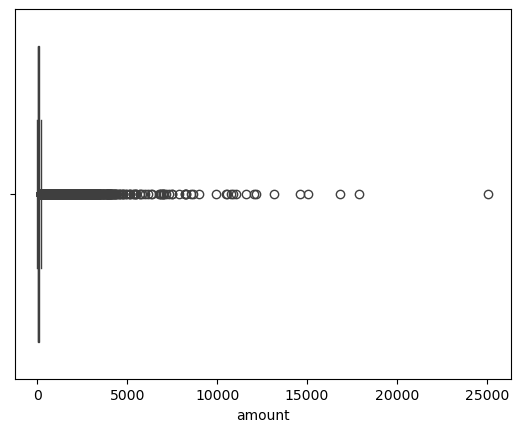

In [20]:
sns.boxplot(x=data['amount'])
plt.show()
# 박스플롯으로 이상치 확인하기 + 시각화

## 새로운 변수 생성


In [23]:
data['time'] = pd.to_datetime(data['time'])
data['hour'] = data['time'].dt.hour

data['distance'] = np.sqrt(
    (data['lat'] - data['merch_lat'])**2 +
    (data['long'] - data['merch_long'])**2
)

data.head()


C:\Users\pc\AppData\Local\Temp\ipykernel_21712\3016649580.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['time'] = pd.to_datetime(data['time'])
C:\Users\pc\AppData\Local\Temp\ipykernel_21712\3016649580.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['hour'] = data['time'].dt.hour
C:\Users\pc\AppData\Local\Temp\ipykernel_21712\3016649580.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


,time,cc_num,merchant,category,amount,first,last,gender,street,city,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,distance
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,0.272310
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,...,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0,0,0.862420
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,...,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0,0,0.622027
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,...,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0,0,0.239327
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,...,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0,0,0.730752


In [ ]:
def hour_func(data):
    data['hour'] = pd.to_datetime(data['trans_date_trans_time']).dt.hour

    def hour_func(x):
        if (x >= 6) & (x < 12):
            return 'morning'
        elif (x >= 12) & (x < 18):
            return 'afternoon' 
        elif (x >= 18) & (x < 23):
            return 'night'
        else:
            return 'late_night'

    data['hour_cat'] = data['hour'].apply(hour_func)
    hour_cnt = pd.read_pickle('./src/hour_cnt.pkl')

    data = data.merge(hour_cnt, on = ['cc_num','hour_cat'], how = 'left')
    cc_df.drop(['rtans_date_trans_time', 'hour', 'hour_cat'], axis=1, inplace=True) 

    return data

In [ ]:
def age_func(data):
    data['dob'] = pd.to_datetime(data['dob']).dt.year
    return data